

```
# author: puru panta (purupanta@uky.edu)
# date: 11/30/2024
# filename: PredictMLDL_Stacked
```



**STEP1: Install and Import libraries required**

In [1]:
import json
import time

In [3]:
!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn

In [4]:
# Mounting google drive if it is already not mounted
def LoadGoogleDrive(googleDriveDir):
  # Link Google Drive
  import os
  # Check if Google Drive is already mounted
  if not os.path.exists(googleDriveDir + "/MyDrive"):
      print("Mounting Google Drive...")
      from google.colab import drive
      drive.mount(googleDriveDir)
  else:
      print("Google Drive is already mounted!")

# Loading the AppConfig file
def LoadAppConfig(json_file_path):
  # Load JSON file into a Python dictionary
  with open(json_file_path, "r") as json_file:
      config_data = json.load(json_file)

  # Print loaded JSON data
  print("AppConfig JSON File Loaded Successfully!")
  # print(config_data)
  return config_data

# Loading the AppLib file
def AppLib_reload_script(script_path):
  # Load AppLib.py
  with open(script_path, 'r') as file:
      script_code = file.read()
      exec(script_code, globals())

**STEP2: Load google-drive, libraries, config file and application library file**

In [5]:
# Mount the google drive
googleDriveFolder = "/content/drive"
LoadGoogleDrive(googleDriveFolder)

# Load the AppConfig json file
json_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/AppConfig.json"
config_data = LoadAppConfig(json_file_path)

# Load AppLib
lib_script_path = config_data["project_location"] + config_data["app_lib_path"] + config_data["app_lib_filename"]
print(f"Loading AppLib from: {lib_script_path}")
AppLib_reload_script(lib_script_path)


Mounting Google Drive...
Mounted at /content/drive
AppConfig JSON File Loaded Successfully!
Loading AppLib from: drive/MyDrive/Colab Notebooks/P_HINTS6/lib/AppLib.py


In [6]:
requirements_path = config_data["project_location"] + config_data["requirements_file_name"]
AppLib.LoadRequirements(requirements_path)

Installing missing packages: ['tf-keras', 'scikit-learn', 'imbalanced-learn', 'xlsxwriter']
Installation completed successfully!
Please restart the runtime for changes to take effect.


**STEP3: Load the original data with filtered columns**

In [7]:
# Define the output file path
ip_file_path = config_data["project_location"] + config_data["op_data_dir"] + config_data["op_file_name_cleaned"];
ip_sheet_name = config_data["op_file_sheet_name_cleaned"]
ip_load_data_cols = config_data["study_cols"]["target_cols"] + config_data["study_cols"]["predictor_cols"] + config_data["study_cols"]["predictor_cols0"]

# Loading cleaded excel data
df_rowColFilteredCleaned = AppLib.load_data(ip_file_path, ip_sheet_name, ip_load_data_cols)


Data Size: 87750, Data Shape: (4875, 18), (Flag: Loaded, original data)


In [8]:
df = df_rowColFilteredCleaned.copy()

**STEP4: Define target and predictors**

In [9]:
predictors = config_data["study_cols"]["predictor_cols"] + config_data["study_cols"]["predictor_cols0"]
target = config_data["study_cols"]["target_cols"]
X, y = AppLib.define_target_predictors(df, predictors, target)

Unique values in the target variable after filtering: [1 0]


**STEP5: Data Standard-Scale**

In [10]:
## Standardize scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**STEP6: SMOTE Data**

In [11]:
# 'smote_data'
# SMOTE is used to handle class imbalance during the training process to help the model learn better representations for the minority class. It artificially generates new samples for the minority class by interpolating between existing samples.
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

**STEP7: Train-Test Split**

In [15]:
# X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Reshape the target variable if necessary
y_train = y_train.to_numpy().ravel()  # Convert to 1D array
y_test = y_test.to_numpy().ravel()    # Convert to 1D array (if needed)


**STEP8: Prediction Starts**

**1. Stacked Model with dynamic routing**

In [13]:
# a. Import the libraries
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [16]:
# b. Train/Test assignments
X_train_stacked = X_train.copy()
y_train_stacked = y_train.copy()
X_test_stacked = X_test.copy()
y_test_stacked = y_test.copy()

In [17]:
# Helper class
def generate_meta_features(X_base, base_models_dict):
    base_probs = []
    for model in base_models_dict.values():
        prob = model.predict_proba(X_base)[:, 1].reshape(-1, 1)
        base_probs.append(prob)
    meta_X = np.hstack([X_base] + base_probs)
    return meta_X
# ====================


In [18]:
# c. Define Base Models
# These are the base learners to choose.
base_models = {
    'rf': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'lr': LogisticRegression(solver='liblinear', random_state=42),
    'svm': SVC(kernel='poly', probability=True, random_state=42, class_weight='balanced'),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'gbm': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# d. Train Each Base Model
trained_base_models = {}
for name, model in base_models.items():
    model.fit(X_train_stacked, y_train_stacked)
    trained_base_models[name] = model



**2. Routing mechanism:**

In [19]:
# Identify the Best Model Per Sample Based on Correctness
# Let each base model generate predictions (probabilities) on training data.
n_samples = X_train_stacked.shape[0]
model_names = list(trained_base_models.keys())
n_models = len(model_names)
correct_matrix = np.zeros((n_samples, n_models))
# Evaluate correctness per sample in the training dataset
for j, (name, model) in enumerate(trained_base_models.items()):
    preds = model.predict(X_train_stacked)
    # Each column in correct_matrix corresponds to one model.
    # Each row represents a training instance.
    # astype(int) converts True -> 1 and False -> 0
    correct_matrix[:, j] = (preds == y_train_stacked).astype(int)

# For each sample, assign the label of the first model that got it right
best_model_labels = np.argmax(correct_matrix, axis=1)


In [20]:
# ✅ New fixed version
meta_X_router = generate_meta_features(X_train_stacked, trained_base_models)


In [21]:
router = RandomForestClassifier(n_estimators=100, random_state=42)
router.fit(meta_X_router, best_model_labels)

RandomForestClassifier(random_state=42)

**3. Working with Test Data**

In [22]:
# Prepare router input for test data
# ✅ New fixed version
meta_X_test_router = generate_meta_features(X_test_stacked, trained_base_models)

confidence_scores = []
for model in trained_base_models.values():
    probs = model.predict_proba(X_train_stacked)[:, 1].reshape(-1, 1)
    conf = np.abs(probs - 0.5)  # higher (1) or lower (0) = more confident
    confidence_scores.append(conf)

# Alternatively, we are now taking Confifence score built from probability score, and use it.
meta_X_router = np.hstack([X_train_stacked] + confidence_scores)

# Use router to choose the best model per sample
selected_model_indices = router.predict(meta_X_test_router)


**4. Predictions**

In [23]:
final_preds = []
final_probs = []

for i, model_idx in enumerate(selected_model_indices):
    model_name = model_names[model_idx]
    selected_model = trained_base_models[model_name]

    x_sample = X_test[i].reshape(1, -1)
    pred = selected_model.predict(x_sample)[0]
    prob = selected_model.predict_proba(x_sample)[0][1]

    final_preds.append(pred)
    final_probs.append(prob)

final_preds = np.array(final_preds)
final_probs = np.array(final_probs)


**5. Plot**

Dynamic Routing Accuracy: 0.95
Dynamic Routing AUC-ROC: 0.99
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       886
           1       0.96      0.95      0.95       882

    accuracy                           0.95      1768
   macro avg       0.95      0.95      0.95      1768
weighted avg       0.95      0.95      0.95      1768



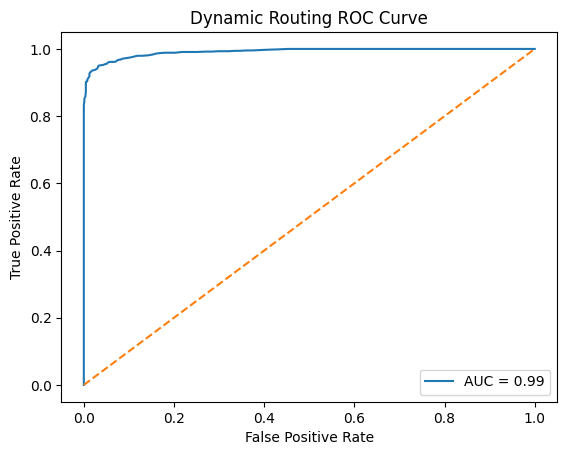

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, final_preds)
roc_auc = roc_auc_score(y_test, final_probs)

print(f"Dynamic Routing Accuracy: {accuracy:.2f}")
print(f"Dynamic Routing AUC-ROC: {roc_auc:.2f}")
print(classification_report(y_test, final_preds))

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, final_probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Dynamic Routing ROC Curve')
plt.legend()
plt.show()
